In [ ]:
! pip install opencxr

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencxr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 52.6 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=d2104ba57f2cab7de5603395dcfb3f8727175beecd4bc586079be46c610213c9
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


### Muntatge de Google Drive
Muntatge de Google Drive per accedir als fitxers del projecte des de Google Colab.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Definició de rutes del dataset
Definició de les rutes cap a les imatges i el fitxer de metadades del dataset NODE21.


In [2]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata_augmented.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"
#PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv


### Càrrega i balanç de classes
Càrrega de les metadades, creació de la ruta de cada imatge PNG i recompte de casos negatius i positius.


In [3]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()
print("Negativos:", num_neg)
print("Positivos:", num_pos)

Negativos: 3748
Positivos: 4427


### Verificació del dataset
Comprovació de les rutes PNG, validació de l’existència dels fitxers i càlcul del balanç de classes (negatius vs positius).


In [4]:
import pandas as pd
import os

# Cargar metadata
df = pd.read_csv(PATH_METADATA)

# Crear nueva ruta hacia PNG
df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

# Mostrar primeras filas con información relevante
print(df[["img_name", "file_path"]].head())

# Verificar si las rutas son válidas
print("\nVerificando existencia de archivos PNG:")

for i in range(5):  # probar las 5 primeras rutas
    fp = df.loc[i, "file_path"]
    exists = os.path.exists(fp)
    print(f"{fp} → {'OK' if exists else 'NO ENCONTRADO'}")

# Contar positivos y negativos
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("\nResumen:")
print("Negativos:", num_neg)
print("Positivos:", num_pos)


    img_name                                          file_path
0  n0239.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
1  n0342.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
2  n0996.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
3  n0418.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
4  n0538.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...

Verificando existencia de archivos PNG:
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0239.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0996.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0418.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0538.png → OK

Resumen:
Negativos: 3748
Positivos: 4427


### Visualització d’anotacions
Mostra una imatge amb les bounding boxes dels nòduls superposades per comprovar visualment les anotacions del dataset.


Mostrando: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png


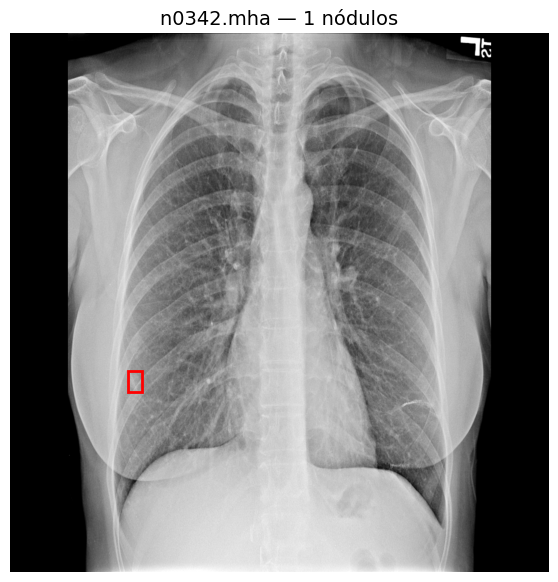

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

def show_png_with_boxes(df, idx):
    # Obtener ruta y nombre del archivo
    path = df.loc[idx, "file_path"]
    img_name = df.loc[idx, "img_name"]
    print("Mostrando:", path)

    # Cargar imagen PNG
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("ERROR: No se pudo cargar la imagen")
        return

    # Normalización para visualización
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Obtener todas las anotaciones de esta imagen
    rows = df[df["file_path"] == path]

    boxes = []
    for _, r in rows.iterrows():
        if r["label"] == 1:
            x1 = float(r["x"])
            y1 = float(r["y"])
            x2 = x1 + float(r["width"])
            y2 = y1 + float(r["height"])
            boxes.append((x1, y1, x2, y2))

    # ------------------------------
    #  VISUALIZACIÓN
    # ------------------------------
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{img_name} — {len(boxes)} nódulos", fontsize=14)

    # Dibujar cada bounding box
    for (x1, y1, x2, y2) in boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.axis("off")
    plt.show()
show_png_with_boxes(df, 1)

### Dataset NODE21 multicanal 
Dataset de PyTorch que carrega imatges PNG, les normalitza i genera una entrada de 3 canals (original, CLAHE i *unsharp mask*), retornant també els `targets` de detecció (bounding boxes i etiquetes) per a Faster R-CNN / RetinaNet.


In [ ]:
from torch.utils.data import Dataset
import torch
import numpy as np
import cv2
import os

class Node21DetectionDatasetPNG(Dataset):
    def __init__(self, df):
        self.df = df.copy()
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]

        # UNA entrada por imagen
        self.images = self.df["file_path"].unique().tolist()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]

        # --------------------------------------------------
        # 1. Cargar imagen (escala de grises)
        # --------------------------------------------------
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

        # Normalización [0,1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        img_255 = (img * 255).astype(np.uint8)

        # --------------------------------------------------
        # 2. CANALES (IGUAL que clasificación)
        # --------------------------------------------------

        # Canal 1: Original
        ch1 = img

        # Canal 2: CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        ch2 = clahe.apply(img_255).astype(np.float32) / 255.0

        # Canal 3: Unsharp Mask
        blur = cv2.GaussianBlur(img, (5,5), 1.0)
        ch3 = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
        ch3 = np.clip(ch3, 0.0, 1.0)

        # Stack (3, H, W)
        image = np.stack([ch1, ch2, ch3], axis=0)
        image = torch.tensor(image, dtype=torch.float32)

        # --------------------------------------------------
        # 3. Targets (bounding boxes)
        # --------------------------------------------------
        rows = self.df[self.df["file_path"] == path]

        boxes = []
        labels = []

        for _, r in rows.iterrows():
            if r["label"] == 1:
                x1 = float(r["x"])
                y1 = float(r["y"])
                x2 = x1 + float(r["width"])
                y2 = y1 + float(r["height"])
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area   = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes  = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area   = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        return image, target

### Dataset NODE21 amb índex estable (detecció)
Dataset de PyTorch que carrega imatges PNG, les normalitza a 3 canals i construeix els `targets` de detecció (bounding boxes, labels, àrea i iscrowd), mantenint un índex fix del DataFrame per garantir consistència en l’accés a les mostres.


In [ ]:
import os
import torch
from torch.utils.data import Dataset
import numpy as np
import cv2

class Node21DetectionDatasetPNG(Dataset):
    def __init__(self, df):
        # Hacemos una copia para no modificar el df original
        self.df = df.copy()

        # Filtro: solo filas con la ruta válida
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]

      
        self.indices = self.df.index.tolist()


    def __len__(self):
        return len(self.indices)


    def __getitem__(self, idx):
        # Obtener el índice REAL en el DataFrame
        real_idx = self.indices[idx]

        # Extraer toda la fila para esa imagen
        row = self.df.loc[real_idx]
        path = row["file_path"]

        # ===============================
        # 1. Cargar imagen PNG
        # ===============================
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = img.astype(np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Convertir a 3 canales
        img3 = np.stack([img, img, img], axis=0)

        # ===============================
        # 2. Obtener TODAS las anotaciones de esta imagen
        # ===============================
        rows = self.df[self.df["file_path"] == path]

        boxes = []
        labels = []

        for _, r in rows.iterrows():
            if r["label"] == 1:
                x1 = float(r["x"])
                y1 = float(r["y"])
                x2 = x1 + float(r["width"])
                y2 = y1 + float(r["height"])
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": iscrowd,
            "image_id": torch.tensor([real_idx])
        }

        return torch.tensor(img3, dtype=torch.float32), target





### Prova del Dataset
Carrega una mostra del `Dataset` i imprimeix la forma de la imatge i l’estructura del `target` per validar que el format és correcte.


In [7]:
dataset = Node21DetectionDatasetPNG(df)

img, target = dataset[1]

print(img.shape)
print(target)

torch.Size([3, 1024, 1024])
{'boxes': tensor([[223., 642., 250., 682.]]), 'labels': tensor([1]), 'area': tensor([1080.]), 'iscrowd': tensor([0]), 'image_id': tensor([1])}


### DataLoaders
Definició del `collate_fn`, divisió del dataset en entrenament i validació i creació dels `DataLoader` per a detecció.


In [ ]:
# 1. Collate
def detection_collate(batch):
    imgs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return imgs, targets

# 2. Split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 3. Datasets
train_dataset = Node21DetectionDatasetPNG(train_df)
val_dataset   = Node21DetectionDatasetPNG(val_df)

# 4. Dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

### Prova del DataLoader
Comprovació ràpida del format dels lots generats pel `DataLoader` (mida del batch, dimensions de la imatge i estructura dels `targets`).


In [15]:
for imgs, targets in train_loader:
    print("Batch size:", len(imgs))
    print("Image shape:", imgs[0].shape)
    print("Targets:", targets[0])
    break

Batch size: 2
Image shape: torch.Size([3, 1024, 1024])
Targets: {'boxes': tensor([[711., 428., 770., 483.]]), 'labels': tensor([1]), 'area': tensor([3245.]), 'iscrowd': tensor([0]), 'image_id': tensor([7365])}


### Visualització d’una mostra del Dataset
Funció per mostrar una imatge del `Dataset` amb les seves bounding boxes i indicar si és positiva (amb nòdul) o negativa (sense detecció).


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_from_dataset(dataset, idx):
 
    # Obtener ruta desde el DataFrame interno
    file_path = dataset.df.iloc[idx]["file_path"]
    file_name = file_path.split("/")[-1]

    img, target = dataset[idx]
    img_np = img[0].numpy()   # canal 0

    fig, ax = plt.subplots(1, figsize=(7,7))
    ax.imshow(img_np, cmap='gray')

    # Título según si hay o no nódulos
    if target["boxes"].shape[0] > 0:
        ax.set_title(
            f"{file_name} — {target['boxes'].shape[0]} nódulo(s)",
            fontsize=14
        )
    else:
        ax.set_title(
            f"{file_name} — NEGATIVA (sin nódulo)",
            fontsize=14
        )

    # Dibujar cajas
    boxes = target["boxes"].numpy()
    for (xmin, ymin, xmax, ymax) in boxes:
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    ax.set_axis_off()
    plt.show()

    print("Archivo mostrado:", file_path)




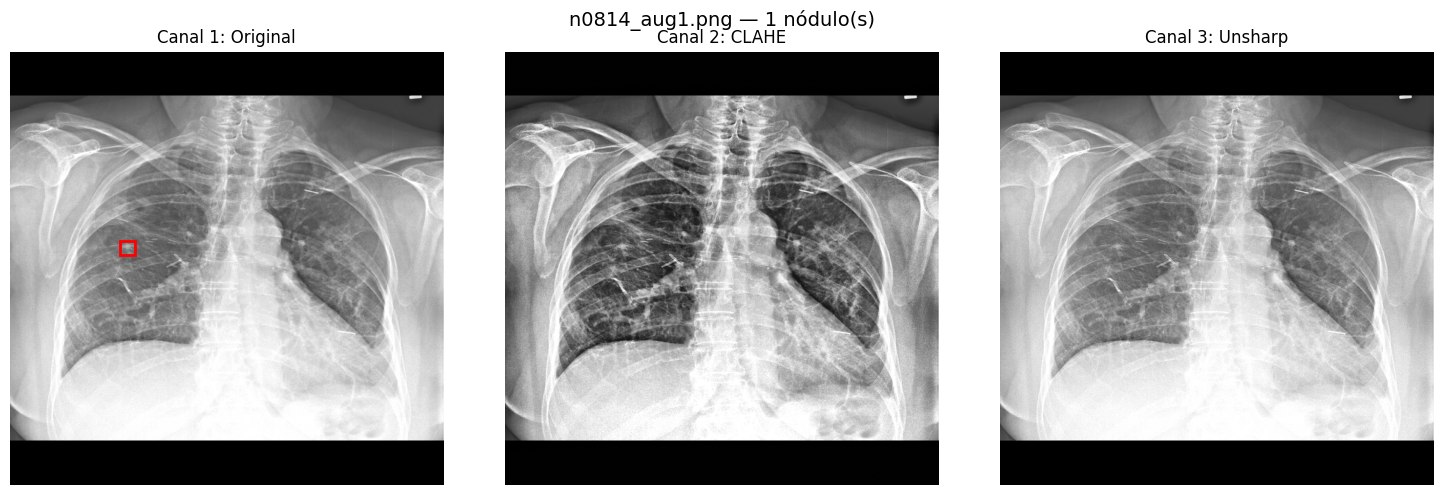

Archivo mostrado: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0814_aug1.png


In [ ]:
show_from_dataset(train_dataset, 1500)

### Inicialització de Faster R-CNN (COCO)
Carrega un Faster R-CNN preentrenat en COCO i substitueix el capçal de classificació per adaptar-lo a 2 classes (fons + nòdul).


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Cargar modelo preentrenado en COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.COCO_V1
)

# 2) Reemplazar la cabeza para 2 clases (background + nódulo)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model = model.to(device)
print("Modelo Faster R-CNN COCO listo.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 181MB/s]


Modelo Faster R-CNN COCO listo.


### Entrenament d’una època
Funció que entrena el model durant una època, calcula la pèrdua total i actualitza els pesos amb l’optimitzador.


In [16]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    loop = tqdm(loader, desc="Entrenando", leave=True)

    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Calcular pérdidas
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)


### Validació d’una època
Funció que avalua el model sobre el conjunt de validació i calcula la pèrdua mitjana sense actualitzar els pesos.


In [ ]:
def evaluate_one_epoch(model, loader, device):
    model.train()   
    total_loss = 0.0

    loop = tqdm(loader, desc="Validando", leave=True)

    with torch.no_grad():
        for images, targets in loop:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

            total_loss += loss.item()
            loop.set_postfix(val_loss=loss.item())

    return total_loss / len(loader)


### Entrenament d’una època
Funció que executa una època d’entrenament del model, calcula la pèrdua total i actualitza els pesos mostrant el progrés amb `tqdm`.


In [18]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc="Entrenando", leave=True)

    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)

### Early stopping
Classe per aturar l’entrenament quan la pèrdua de validació deixa de millorar durant diverses èpoques.


In [19]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True

        return False


### Entrenament complet i guardat de models
Bucle principal d’entrenament i validació amb AdamW, guardat de checkpoints per època i del millor model segons la pèrdua de validació, amb suport d’early stopping.


In [ ]:
import torch.optim as optim
import os
from datetime import datetime

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"


# Timestamp único por ejecución
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Run ID: {RUN_ID}")


optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


num_epochs = 20
early_stopper = EarlyStopping(patience=20, min_delta=0.0001)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = evaluate_one_epoch(model, val_loader, device)

    print(f"Epoch {epoch+1}:")
    print(f"  → Train Loss: {train_loss:.4f}")
    print(f"  → Val Loss:   {val_loss:.4f}")

    # Guardar checkpoint por epoch 
    checkpoint_path = (
        f"{MODEL_DIR}/checkpoint_coco_monocanal_desbalanceado_epoch_{epoch+1:02d}_{RUN_ID}.pth"
    )
    torch.save(model.state_dict(), checkpoint_path)

    # Guardar mejor modelo de ESTA ejecución
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_path = (
            f"{MODEL_DIR}/best_coco_monocanal_desbalanceado_frcnn_node21_{RUN_ID}.pth"
        )
        torch.save(model.state_dict(), best_model_path)

        print("Guardado nuevo MEJOR MODELO de la ejecución")

    # Early stopping
    if early_stopper.step(val_loss):
        print(f"\n Early stopping activado en Epoch {epoch+1}")
        print(f"Mejor epoch = {epoch+1 - early_stopper.patience}")
        break


Run ID: 20251229_173827

===== Epoch 1/20 =====


Validando: 100%|██████████| 818/818 [02:21<00:00,  5.78it/s, val_loss=0.00536]


Epoch 1:
  → Train Loss: 0.1231
  → Val Loss:   0.0941
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 2/20 =====


Validando: 100%|██████████| 818/818 [02:21<00:00,  5.79it/s, val_loss=0.012]


Epoch 2:
  → Train Loss: 0.1051
  → Val Loss:   0.0910
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 3/20 =====


...

Epoch 18:
  → Train Loss: 0.0250
  → Val Loss:   0.1665

===== Epoch 19/20 =====


Validando: 100%|██████████| 818/818 [02:20<00:00,  5.83it/s, val_loss=5.93e-7]


Epoch 19:
  → Train Loss: 0.0250
  → Val Loss:   0.1650

===== Epoch 20/20 =====


Validando: 100%|██████████| 818/818 [02:20<00:00,  5.82it/s, val_loss=2.41e-5]


Epoch 20:
  → Train Loss: 0.0236
  → Val Loss:   0.1814


### Dataset NODE21 multicanal (detecció)
Dataset de PyTorch que genera una entrada de 3 canals (original, CLAHE i *unsharp mask*) a partir d’imatges PNG i construeix els `targets` de detecció (bounding boxes i etiquetes) per entrenar models com Faster R-CNN o RetinaNet.


In [ ]:
from torch.utils.data import Dataset, DataLoader
class Node21DetectionDatasetPNG(Dataset):
    def __init__(self, df):
        self.df = df.copy()
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]

        # UNA entrada por imagen
        self.images = self.df["file_path"].unique().tolist()

    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
      path = self.images[idx]

      # ---------------------------
      # 1. Cargar imagen original
      # ---------------------------
      img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
      img = (img - img.min()) / (img.max() - img.min() + 1e-8)

      img_255 = (img * 255).astype(np.uint8)

      # ---------------------------
      # 2. Canal 1: original
      # ---------------------------
      ch1 = img

      # ---------------------------
      # 3. Canal 2: CLAHE
      # ---------------------------
      # Canal 2: CLAHE
      clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
      ch2 = clahe.apply((img * 255).astype(np.uint8)).astype(np.float32) / 255.0

      # ---------------------------
      # 4. Canal 3: Unsharp Mask
      # ---------------------------
      blur = cv2.GaussianBlur(img, (5,5), 1.0)
      ch3 = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
      ch3 = np.clip(ch3, 0.0, 1.0)

      # ---------------------------
      # 5. Stack  3 canales
      # ---------------------------
      img3 = np.stack([ch1, ch2, ch3], axis=0)

      # ---------------------------
      # 6. Targets (IGUAL que antes)
      # ---------------------------
      rows = self.df[self.df["file_path"] == path]

      boxes = []
      labels = []

      for _, r in rows.iterrows():
          if r["label"] == 1:
              x1 = float(r["x"])
              y1 = float(r["y"])
              x2 = x1 + float(r["width"])
              y2 = y1 + float(r["height"])
              boxes.append([x1, y1, x2, y2])
              labels.append(1)

      if len(boxes) == 0:
          boxes = torch.zeros((0,4), dtype=torch.float32)
          labels = torch.zeros((0,), dtype=torch.int64)
          area = torch.zeros((0,), dtype=torch.float32)
      else:
          boxes = torch.tensor(boxes, dtype=torch.float32)
          labels = torch.tensor(labels, dtype=torch.int64)
          area = (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])

      target = {
          "boxes": boxes,
          "labels": labels,
          "area": area,
          "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
          "image_id": torch.tensor([idx])
      }

      return torch.tensor(img3, dtype=torch.float32), target

### Càrrega i balanç de classes
Càrrega de les metadades, construcció de les rutes de les imatges PNG i recompte de mostres negatives i positives.


In [ ]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()
print("Negativos:", num_neg)
print("Positivos:", num_pos)

Negativos: 3748
Positivos: 4427


### Split i DataLoaders
Divisió del dataset en entrenament i validació, definició del `collate_fn` i creació dels `DataLoader` per a detecció.


In [ ]:
# 1. Collate
def detection_collate(batch):
    imgs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return imgs, targets

# 2. Split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 3. Datasets
train_dataset = Node21DetectionDatasetPNG(train_df)
val_dataset   = Node21DetectionDatasetPNG(val_df)

# 4. Dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

### Inicialització de Faster R-CNN (COCO)
Carrega un Faster R-CNN preentrenat en COCO i adapta el capçal de classificació a 2 classes (fons + nòdul).


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Cargar modelo preentrenado en COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.COCO_V1
)

# 2) Reemplazar la cabeza para 2 clases (background + nódulo)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model = model.to(device)
print("Modelo Faster R-CNN COCO listo.")

Modelo Faster R-CNN COCO listo.


### Entrenament complet i guardat de models
Bucle d’entrenament i validació amb AdamW, guardat de checkpoints per època i del millor model segons la pèrdua de validació, amb suport d’early stopping.


In [ ]:
import torch.optim as optim
import os
from datetime import datetime

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"


# Timestamp único por ejecución
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Run ID: {RUN_ID}")


optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

num_epochs = 20
early_stopper = EarlyStopping(patience=20, min_delta=0.0001)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = evaluate_one_epoch(model, val_loader, device)

    print(f"Epoch {epoch+1}:")
    print(f"  → Train Loss: {train_loss:.4f}")
    print(f"  → Val Loss:   {val_loss:.4f}")

    # Guardar checkpoint por epoch 
    checkpoint_path = (
        f"{MODEL_DIR}/checkpoint_coco_3canales_desbalanceado_epoch_{epoch+1:02d}_{RUN_ID}.pth"
    )
    torch.save(model.state_dict(), checkpoint_path)

    # Guardar mejor modelo de ESTA ejecución
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_path = (
            f"{MODEL_DIR}/best_coco_3canales_desbalanceado_frcnn_node21_{RUN_ID}.pth"
        )
        torch.save(model.state_dict(), best_model_path)

        print("Guardado nuevo MEJOR MODELO de la ejecución")

    # Early stopping
    if early_stopper.step(val_loss):
        print(f"\n Early stopping activado en Epoch {epoch+1}")
        print(f"Mejor epoch = {epoch+1 - early_stopper.patience}")
        break

Run ID: 20251230_014536

===== Epoch 1/20 =====


Validando: 100%|██████████| 510/510 [01:27<00:00,  5.82it/s, val_loss=0.000509]


Epoch 1:
  → Train Loss: 0.0600
  → Val Loss:   0.0644
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 2/20 =====


Validando: 100%|██████████| 510/510 [01:27<00:00,  5.81it/s, val_loss=0.00492]


Epoch 2:
  → Train Loss: 0.0486
  → Val Loss:   0.0520
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 3/20 =====


...

Validando: 100%|██████████| 510/510 [01:27<00:00,  5.81it/s, val_loss=0.00317]


Epoch 9:
  → Train Loss: 0.0265
  → Val Loss:   0.0612

===== Epoch 10/20 =====


Validando: 100%|██████████| 510/510 [01:27<00:00,  5.85it/s, val_loss=0.00845]


Epoch 10:
  → Train Loss: 0.0264
  → Val Loss:   0.0589

===== Epoch 11/20 =====


Entrenando:  15%|█▍        | 288/1981 [01:55<11:17,  2.50it/s, loss=9.42e-7]

### Definició de rutes del dataset
Definició de les rutes cap a les imatges i el fitxer de metadades del dataset NODE21.


In [8]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata_augmented.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"


print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv


### Càrrega i balanç de classes
Càrrega de les metadades, creació de la ruta de cada imatge PNG i recompte de mostres negatives i positives.


In [9]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()
print("Negativos:", num_neg)
print("Positivos:", num_pos)

Negativos: 3748
Positivos: 4427


### Split i DataLoaders
Divisió del dataset en entrenament i validació, definició del `collate_fn` i creació dels `DataLoader` per a detecció.


In [10]:
# 1. Collate
def detection_collate(batch):
    imgs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return imgs, targets

# 2. Split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 3. Datasets
train_dataset = Node21DetectionDatasetPNG(train_df)
val_dataset   = Node21DetectionDatasetPNG(val_df)

# 4. Dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

### Inicialització de Faster R-CNN (COCO)
Carrega un Faster R-CNN preentrenat en COCO i adapta el capçal final a 2 classes (fons + nòdul) per al dataset NODE21.


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Cargar modelo preentrenado en COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.COCO_V1
)

# 2) Reemplazar la cabeza para 2 clases (background + nódulo)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model = model.to(device)
print("Modelo Faster R-CNN COCO listo.")

Modelo Faster R-CNN COCO listo.


### Fine-tuning de Faster R-CNN (COCO → NODE21)
Carrega un Faster R-CNN preentrenat en COCO, adapta el capçal a 2 classes i aplica *fine-tuning* parcial congelant el backbone i deixant entrenables només `layer4` i la FPN.


In [11]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------------------------
# 1) Cargar modelo preentrenado en COCO
# -------------------------------------------------
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.COCO_V1
)

# -------------------------------------------------
# 2) Reemplazar la cabeza para NODE21 (2 clases)
# -------------------------------------------------
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# -------------------------------------------------
# 3) Congelar todo el backbone
# -------------------------------------------------
for p in model.backbone.body.parameters():
    p.requires_grad = False

# -------------------------------------------------
# 4) Descongelar SOLO layer4 (adaptación dominio)
# -------------------------------------------------
for name, p in model.backbone.body.named_parameters():
    if name.startswith("layer4"):
        p.requires_grad = True

# -------------------------------------------------
# 5) Descongelar FPN 
# -------------------------------------------------
for name, p in model.backbone.named_parameters():
    if "fpn" in name:
        p.requires_grad = True

# -------------------------------------------------
# 6) Device + train
# -------------------------------------------------
model.to(device)
model.train()

print("Faster R-CNN COCO con layer4 + FPN entrenables listo")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 257MB/s]


Faster R-CNN COCO con layer4 + FPN entrenables listo


### Visualització multicanal del Dataset
Funció adaptada a 3 canals que mostra els canals (original, CLAHE i *unsharp*) d’una mostra del `Dataset` i dibuixa les bounding boxes sobre el canal original per validar el preprocessament.


In [ ]:
# adaptada a 3 canales
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_from_dataset(dataset, idx):
   

    # Ruta REAL usada por el dataset
    file_path = dataset.images[idx]
    file_name = file_path.split("/")[-1]

    img, target = dataset[idx]   # img: (3, H, W)
    img_np = img.numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    channel_titles = [
        "Canal 1: Original",
        "Canal 2: CLAHE",
        "Canal 3: Unsharp"
    ]

    for i, ax in enumerate(axes):
        ax.imshow(img_np[i], cmap="gray")
        ax.set_title(channel_titles[i], fontsize=12)
        ax.axis("off")

        # Dibujar bounding boxes SOLO sobre el canal original
        if i == 0:
            for (xmin, ymin, xmax, ymax) in target["boxes"].numpy():
                rect = patches.Rectangle(
                    (xmin, ymin),
                    xmax - xmin,
                    ymax - ymin,
                    linewidth=2,
                    edgecolor="red",
                    facecolor="none"
                )
                ax.add_patch(rect)

    # Título general
    if target["boxes"].shape[0] > 0:
        fig.suptitle(
            f"{file_name} — {target['boxes'].shape[0]} nódulo(s)",
            fontsize=14
        )
    else:
        fig.suptitle(
            f"{file_name} — NEGATIVA (sin nódulo)",
            fontsize=14
        )

    plt.tight_layout()
    plt.show()

    print("Archivo mostrado:", file_path)

In [13]:
show_from_dataset(train_dataset, 14)

AttributeError: 'Node21DetectionDatasetPNG' object has no attribute 'images'

### Entrenament complet i guardat de models
Bucle d’entrenament i validació amb AdamW, guardat de checkpoints per època i del millor model segons la pèrdua de validació, amb suport d’early stopping.


In [20]:
import torch.optim as optim
import os
from datetime import datetime

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"


# Timestamp único por ejecución
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Run ID: {RUN_ID}")


optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

num_epochs = 20
early_stopper = EarlyStopping(patience=20, min_delta=0.0001)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = evaluate_one_epoch(model, val_loader, device)

    print(f"Epoch {epoch+1}:")
    print(f"  → Train Loss: {train_loss:.4f}")
    print(f"  → Val Loss:   {val_loss:.4f}")

    # Guardar checkpoint por epoch 
    checkpoint_path = (
        f"{MODEL_DIR}/checkpoint_coco_1canal_descongelado_balanceado_epoch_{epoch+1:02d}_{RUN_ID}.pth"
    )
    torch.save(model.state_dict(), checkpoint_path)

    # Guardar mejor modelo de ESTA ejecución
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_path = (
            f"{MODEL_DIR}/best_coco_1canal_descongelado_balanceado_frcnn_node21_{RUN_ID}.pth"
        )
        torch.save(model.state_dict(), best_model_path)

        print("Guardado nuevo MEJOR MODELO de la ejecución")

    # Early stopping
    if early_stopper.step(val_loss):
        print(f"\n Early stopping activado en Epoch {epoch+1}")
        print(f"Mejor epoch = {epoch+1 - early_stopper.patience}")
        break

Run ID: 20251231_084626

===== Epoch 1/20 =====


Validando: 100%|██████████| 818/818 [12:17<00:00,  1.11it/s, val_loss=0.00537]


Epoch 1:
  → Train Loss: 0.1153
  → Val Loss:   0.0935
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 2/20 =====


Validando: 100%|██████████| 818/818 [02:25<00:00,  5.62it/s, val_loss=0.00552]


Epoch 2:
  → Train Loss: 0.0975
  → Val Loss:   0.0837
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 3/20 =====


...

Epoch 16:
  → Train Loss: 0.0351
  → Val Loss:   0.2554

===== Epoch 17/20 =====


Validando: 100%|██████████| 818/818 [02:25<00:00,  5.60it/s, val_loss=3.39e-6]


Epoch 17:
  → Train Loss: 0.0355
  → Val Loss:   0.3327

===== Epoch 18/20 =====


Entrenando:  29%|██▉       | 959/3270 [05:10<12:28,  3.09it/s, loss=0.0375]


KeyboardInterrupt: 

### Càrrega de checkpoints del model
Selecció d’un fitxer de pesos (`.pth`) d’entre diferents checkpoints disponibles i càrrega del model entrenat per executar inferència o validació.


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"
MODEL_PATH = f"{MODEL_DIR}/best_model.pth"
MODEL_PATH = f"{MODEL_DIR}/node21_v2.2_png_frcnn_coco_monocanal_original_best_20251216_184035.pth"
MODEL_PATH = f"{MODEL_DIR}/best_model_rcnn_balanceado_v1.pth"
MODEL_PATH = f"{MODEL_DIR}/checkpoint_epoch_07_20251217_071423.pth"
MODEL_PATH = f"{MODEL_DIR}/checkpoint_epoch_10_20251226_124055.pth"
MODEL_PATH = f"{MODEL_DIR}/best_frcnn_node21_20251226_180828.pth"
MODEL_PATH = f"{MODEL_DIR}/best_frcnn_node21_20251228_064854.pth"

#MODEL_PATH = f"{MODEL_DIR}/best_model.pth"

#MODEL_PATH = f"{MODEL_DIR}/node21_v2.2_png_frcnn_coco_monocanal_original_checkpoint_epoch_05_20251216_184035.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print("Modelo cargado correctamente.")

Modelo cargado correctamente.


### Visualització de prediccions
Funció per mostrar les deteccions del model sobre una imatge del dataset, filtrant per un llindar de confiança i superposant les bounding boxes predides.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def show_prediction(model, dataset, idx, score_thresh=0.3):
    model.eval()

    img, target = dataset[idx]
    img_np = img[0].numpy()
    image = img.to(device)

    with torch.no_grad():
        pred = model([image])[0]

    pred_boxes = pred["boxes"].cpu().numpy()
    pred_scores = pred["scores"].cpu().numpy()

    # Filtrar predicciones por score
    keep = pred_scores >= score_thresh
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]

    # Dibujar
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_np, cmap='gray')

    # GT
    #for (x1, y1, x2, y2) in target["boxes"]:
    #    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
    #                             linewidth=2, edgecolor='lime', facecolor='none')
    #    ax.add_patch(rect)

    # Predicciones
    for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1, f"{s:.2f}", color="yellow", fontsize=10)

    plt.title(f"GT = verde • Pred = rojo (idx={idx})")
    plt.axis("off")
    plt.show()


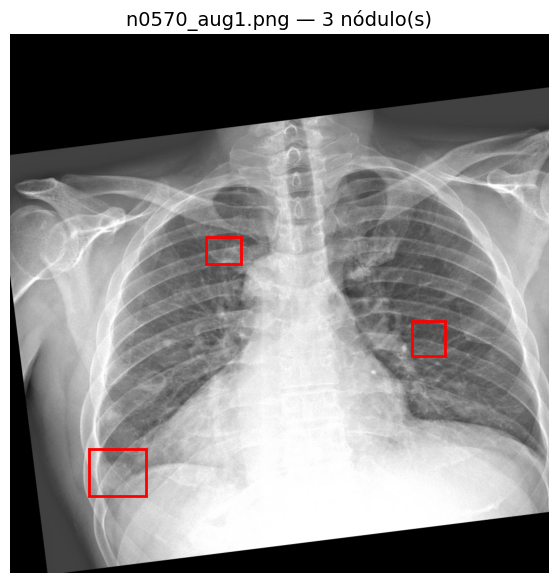

Archivo mostrado: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0570_aug1.png


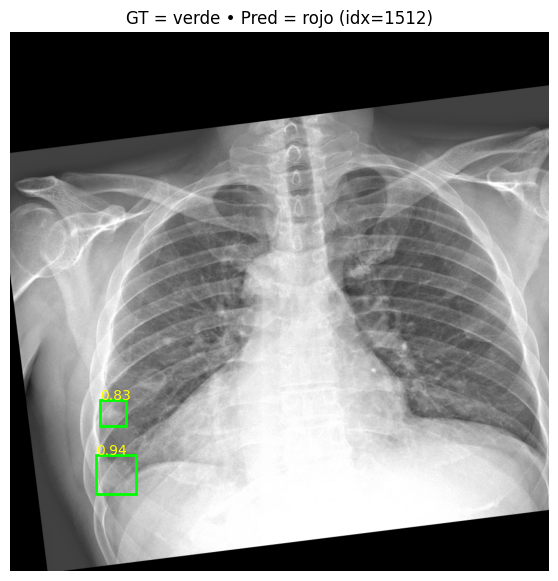

In [ ]:
show_from_dataset(train_dataset, 1512)      # Ground truth
show_prediction(model, train_dataset, 1512) # Predicción


### Comparació GT vs predicció (imatge única)
Funció que carrega una imatge concreta, construeix les bounding boxes de *ground truth* a partir del metadata i executa inferència amb el model, mostrant en dues figures separades el GT i les prediccions filtrades per un llindar de confiança.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import cv2

def show_gt_and_prediction(model, df, file_path, score_thresh=0.3):
 


    # -----------------------------
    # 1. Obtener filas del CSV
    # -----------------------------
    rows = df[df["file_path"] == file_path]

    if len(rows) == 0:
        raise ValueError(f"No existe información en el metadata para: {file_path}")

    # -----------------------------
    # 2. Cargar imagen
    # -----------------------------
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    img = img.astype(np.float32)

    # Normalizar
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Crear tensor para el modelo (3 canales)
    img3 = np.stack([img_norm, img_norm, img_norm], axis=0)
    img_tensor = torch.tensor(img3, dtype=torch.float32).to(device)

    # -----------------------------
    # 3. Construir bounding boxes GT
    # -----------------------------
    gt_boxes = []
    for _, r in rows.iterrows():
        if r["label"] == 1:
            x1 = r["x"]
            y1 = r["y"]
            x2 = x1 + r["width"]
            y2 = y1 + r["height"]
            gt_boxes.append((x1, y1, x2, y2))

    # -----------------------------
    # 4. Inferencia modelo
    # -----------------------------
    model.eval()
    with torch.no_grad():
        pred = model([img_tensor])[0]

    pred_boxes = pred["boxes"].cpu().numpy()
    pred_scores = pred["scores"].cpu().numpy()

    keep = pred_scores >= score_thresh
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]


    # ============================================================
    #  FIGURA 1: Imagen original con bounding boxes GT (ROJO)
    # ============================================================
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_norm, cmap="gray")

    for (x1, y1, x2, y2) in gt_boxes:
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)

    ax.set_title(f"Imagen Original — GT (ROJO)\n{file_path.split('/')[-1]}")
    ax.axis("off")
    plt.show()


    # ============================================================
    #  FIGURA 2: Predicción del modelo (rojo)
    # ============================================================
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_norm, cmap="gray")

    for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1, f"{s:.2f}", color="yellow", fontsize=10)

    ax.set_title(f"Predicción del modelo — Pred (rojo)\nScore ≥ {score_thresh}")
    ax.axis("off")
    plt.show()



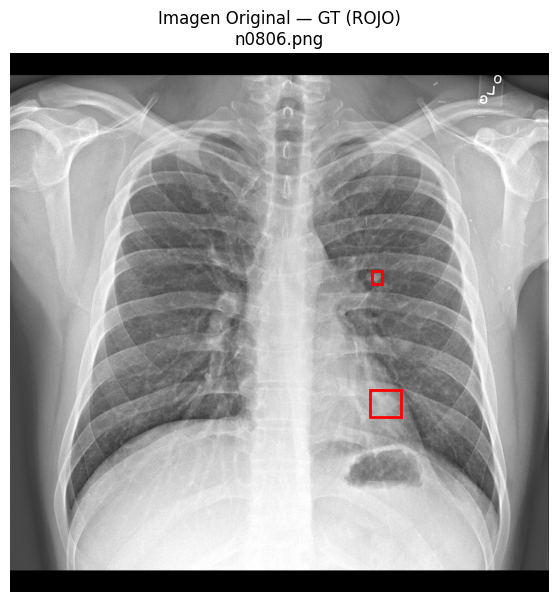

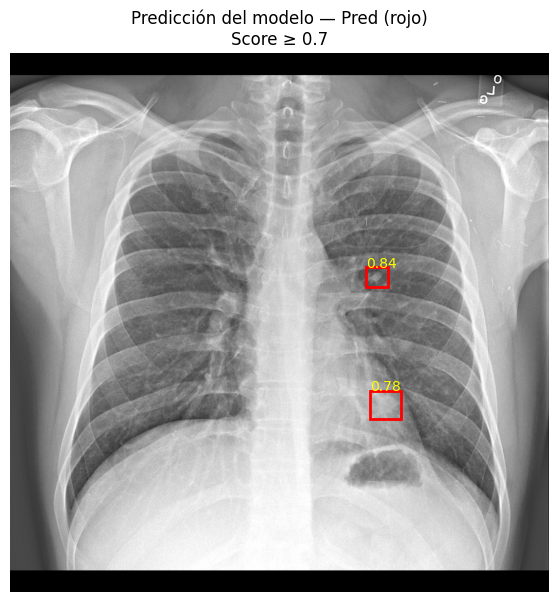

In [ ]:
file_path = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0806.png"
show_gt_and_prediction(
    model,
    df,
    file_path,
    score_thresh=0.7
)



### Càlcul de la IoU mitjana
Funció per calcular la *mean IoU* del model sobre el dataset, comparant cada bounding box de *ground truth* amb la millor predicció disponible (filtrada per un llindar de confiança).


In [ ]:
import torch

def mean_iou(model, dataset, device, score_thresh=0.5):
    model.eval()
    ious = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            img, target = dataset[idx]
            img = img.to(device)

            pred = model([img])[0]

            if len(target["boxes"]) == 0 or len(pred["boxes"]) == 0:
                continue

            scores = pred["scores"].cpu().numpy()
            boxes_pred = pred["boxes"].cpu().numpy()

            keep = scores >= score_thresh
            boxes_pred = boxes_pred[keep]

            if len(boxes_pred) == 0:
                continue

            # Para cada GT, cogemos la mejor IoU
            for gt_box in target["boxes"].numpy():
                best_iou = 0.0
                for pb in boxes_pred:
                    best_iou = max(best_iou, compute_iou(gt_box, pb))
                ious.append(best_iou)

    return np.mean(ious) if len(ious) > 0 else 0.0


### Funció IoU (Intersection over Union)
Implementació del càlcul de la IoU entre dues bounding boxes, mesurant el solapament entre la intersecció i la unió de les àrees.


In [ ]:
import numpy as np

def compute_iou(boxA, boxB):
   
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union = areaA + areaB - inter_area

    if union == 0:
        return 0.0

    return inter_area / union

In [ ]:
#coco original
miou = mean_iou(model, val_dataset, device)
print("Mean IoU:", miou)

Mean IoU: 0.6892569614186665


### Recol·lecció de deteccions per avaluació
Funció que executa inferència sobre tot el dataset i emmagatzema, per a cada imatge, les bounding boxes de *ground truth* i les prediccions del model (amb scores), per poder calcular mètriques posteriors.


In [ ]:
def collect_detections(model, dataset, device, score_thresh=0.01):
    model.eval()
    detections = []
    gt_count = 0

    with torch.no_grad():
        for idx in range(len(dataset)):
            img, target = dataset[idx]
            img = img.to(device)

            gt_boxes = target["boxes"].numpy()
            gt_count += len(gt_boxes)

            pred = model([img])[0]
            boxes = pred["boxes"].cpu().numpy()
            scores = pred["scores"].cpu().numpy()

            keep = scores >= score_thresh
            boxes = boxes[keep]
            scores = scores[keep]

            detections.append({
                "gt_boxes": gt_boxes,
                "pred_boxes": boxes,
                "scores": scores
            })

    return detections, gt_count

### Càlcul d’Average Precision (AP)
Implementació manual de l’AP: es recullen totes les prediccions, s’ordenen per score, es determinen *true positives* i *false positives* segons un llindar d’IoU i es calcula l’àrea sota la corba Precisió–Recall.


In [ ]:
def average_precision(detections, gt_count, iou_thresh=0.5):
    preds = []

    for img_id, det in enumerate(detections):
        for box, score in zip(det["pred_boxes"], det["scores"]):
            preds.append({
                "img_id": img_id,
                "box": box,
                "score": score
            })

    # Ordenar por score descendente
    preds = sorted(preds, key=lambda x: x["score"], reverse=True)

    tp = np.zeros(len(preds))
    fp = np.zeros(len(preds))

    used_gts = {i: set() for i in range(len(detections))}

    for i, p in enumerate(preds):
        gt_boxes = detections[p["img_id"]]["gt_boxes"]
        best_iou = 0
        best_gt = -1

        for j, gt in enumerate(gt_boxes):
            if j in used_gts[p["img_id"]]:
                continue
            iou = compute_iou(p["box"], gt)
            if iou > best_iou:
                best_iou = iou
                best_gt = j

        if best_iou >= iou_thresh:
            tp[i] = 1
            used_gts[p["img_id"]].add(best_gt)
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)

    recall = cum_tp / (gt_count + 1e-8)
    precision = cum_tp / (cum_tp + cum_fp + 1e-8)

    # AP = área bajo la curva P–R
    #ap = np.trapz(precision, recall)
    ap = np.trapezoid(precision, recall)
    return ap

### mAP@0.50 (avaluació bàsica)
Funció que calcula l’AP (mAP@0.50) del model sobre el dataset utilitzant les deteccions recollides i un llindar d’IoU definit.


In [ ]:
def map_50(model, dataset, device):
    detections, gt_count = collect_detections(model, dataset, device)
    ap50 = average_precision(detections, gt_count, iou_thresh=0.01)
    return ap50

In [ ]:
#el del cuaderno
map50 = map_50(model, val_dataset, device)
print("mAP@0.5:", map50)

mAP@0.5: 0.6332605133654239
